# FitScalingLaw

This notebook analyzes the FitScalingLaw sweep over $p \in \{2^9,2^{10},\ldots,2^{17}\}$ and $\beta \in \{1,\ldots,15\}$. The runs use minibatch SGD with batch size $2^{11}$ and $T_{\mathrm{minibatch}}=2000p/2^{11}$ steps so each example is seen $2000$ times on average. Each beta uses the fitted GD learning-rate transition from `notebooks/pareto_plots.ipynb`:

$$ \mathrm{LR}(\beta)=0.101\left(\frac{0.644}{0.101}\right)^{\frac{1}{1+(\beta/2.27)^{-6.9/\ln 10}}}. $$

The analysis fits $\log(\mathrm{test\ loss}) = a + b\log(p)$ for each $\beta$ and reports the scaling exponent as $-b$.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / 'scripts').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.process_scaling_law import (
    final_losses,
    fit_scaling_exponents,
    load_scaling_results,
)

run_root = repo_root / 'runs/fit_scaling_law_20260510_184248'
metric = 'test_xent'
plot_dir = run_root
plot_dir.mkdir(parents=True, exist_ok=True)
run_root.resolve()

/tmp/ipykernel_3191952/2363694421.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


PosixPath('/n/home07/ssainathan/workplace/temperature_experiments/two_layer_test/runs/fit_scaling_law_20260510_184248')

In [2]:
df = load_scaling_results(run_root)
df.to_csv(run_root / 'scaling_law_results.csv', index=False)

final = final_losses(df, metric)
if 'mode' not in final.columns:
    final['mode'] = 'population'
else:
    final['mode'] = final['mode'].fillna('population')
final.to_csv(run_root / 'scaling_law_final_losses.csv', index=False)
final.head()

,beta,p,mode,minibatch_size,target_passes,effective_passes,lr,step,train_xent,test_xent,train_logit_mse,test_logit_mse
0,1.0,512,minibatch2048,2048,2000,2000.0,0.116909,500,3.959861,4.818392,1.154702,1.164094
1,1.0,1024,minibatch2048,2048,2000,2000.0,0.116909,1000,3.945598,4.749521,1.123318,1.125775
2,1.0,2048,minibatch2048,2048,2000,2000.0,0.116909,2000,3.950212,4.720592,1.042786,1.045663
3,1.0,4096,minibatch2048,2048,2000,2000.0,0.116909,4000,3.958854,4.636064,0.896690,0.902039
4,1.0,8192,minibatch2048,2048,2000,2000.0,0.116909,8000,3.977214,4.534286,0.699049,0.702361


In [3]:
fits = fit_scaling_exponents(final, metric)
fits.to_csv(run_root / 'scaling_law_exponents.csv', index=False)
fits

,beta,metric,slope,scaling_exponent,intercept,r2,n_points
0,1.0,test_xent,-0.023381,0.023381,1.722302,0.985596,9
1,2.0,test_xent,-0.062393,0.062393,1.919749,0.964214,9
2,3.0,test_xent,-0.102880,0.102880,2.086002,0.950588,9
3,4.0,test_xent,-0.140431,0.140431,2.248546,0.952424,9
4,5.0,test_xent,-0.172834,0.172834,2.405884,0.951658,9
5,6.0,test_xent,-0.198835,0.198835,2.543452,0.959796,9
6,7.0,test_xent,-0.220699,0.220699,2.666787,0.966066,9
7,8.0,test_xent,-0.239910,0.239910,2.788716,0.969908,9
8,9.0,test_xent,-0.253606,0.253606,2.868670,0.972970,9
9,10.0,test_xent,-0.263693,0.263693,2.930731,0.977513,9


In [4]:
# Fit using only the first four p values per beta.
rows = []
for beta, group in final.groupby('beta', sort=True):
    head = group.sort_values('p').head(4)
    x = np.log(head['p'].to_numpy(dtype=float))
    y = np.log(head[metric].to_numpy(dtype=float))
    slope, intercept = np.polyfit(x, y, deg=1)
    rows.append({'beta': beta, 'slope': slope, 'intercept': intercept, 'scaling_exponent': -slope, 'n_points': len(head)})
fits_first4 = pd.DataFrame(rows)
fits_first4.to_csv(run_root / 'scaling_law_exponents_first4.csv', index=False)
fits_first4

,beta,slope,intercept,scaling_exponent,n_points
0,1.0,-0.017577,1.681996,0.017577,4
1,2.0,-0.067706,1.966745,0.067706,4
2,3.0,-0.141708,2.379246,0.141708,4
3,4.0,-0.192483,2.641585,0.192483,4
4,5.0,-0.240928,2.917821,0.240928,4
5,6.0,-0.262917,3.028858,0.262917,4
6,7.0,-0.280146,3.120195,0.280146,4
7,8.0,-0.289976,3.177035,0.289976,4
8,9.0,-0.296741,3.208317,0.296741,4
9,10.0,-0.302142,3.235167,0.302142,4


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


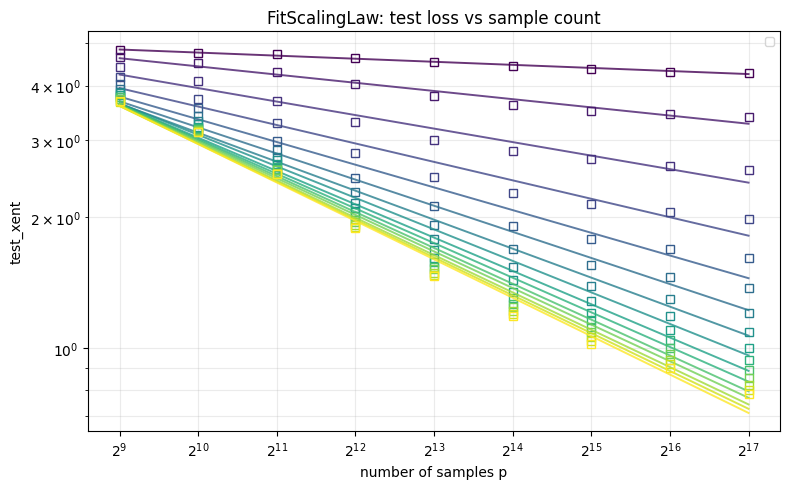

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.get_cmap('viridis')
betas = sorted(final['beta'].unique())
for color_idx, beta in enumerate(betas):
    group = final[final['beta'] == beta].sort_values('p')
    fit = fits[fits['beta'] == beta].iloc[0]
    color = cmap(color_idx / max(1, len(betas) - 1))
    p_grid = np.geomspace(group['p'].min(), group['p'].max(), 200)
    y_fit = np.exp(fit['intercept']) * p_grid ** fit['slope']
    full_batch = group[group['mode'] == 'population']
    minibatch = group[group['mode'] != 'population']
    if not full_batch.empty:
        ax.plot(full_batch['p'], full_batch[metric], marker='o', linestyle='', color=color, label=f"beta={beta:g}, slope={fit['slope']:.3f}")
    if not minibatch.empty:
        ax.plot(minibatch['p'], minibatch[metric], marker='s', linestyle='', color=color, markerfacecolor='none')
    ax.plot(p_grid, y_fit, linewidth=1.4, color=color, alpha=0.8)

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('number of samples p')
ax.set_ylabel(metric)
ax.set_title('FitScalingLaw: test loss vs sample count')
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize='small', ncols=2)
fig.tight_layout()
fig.savefig(plot_dir / f'fit_scaling_law_{metric}_loglog.png', dpi=180)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


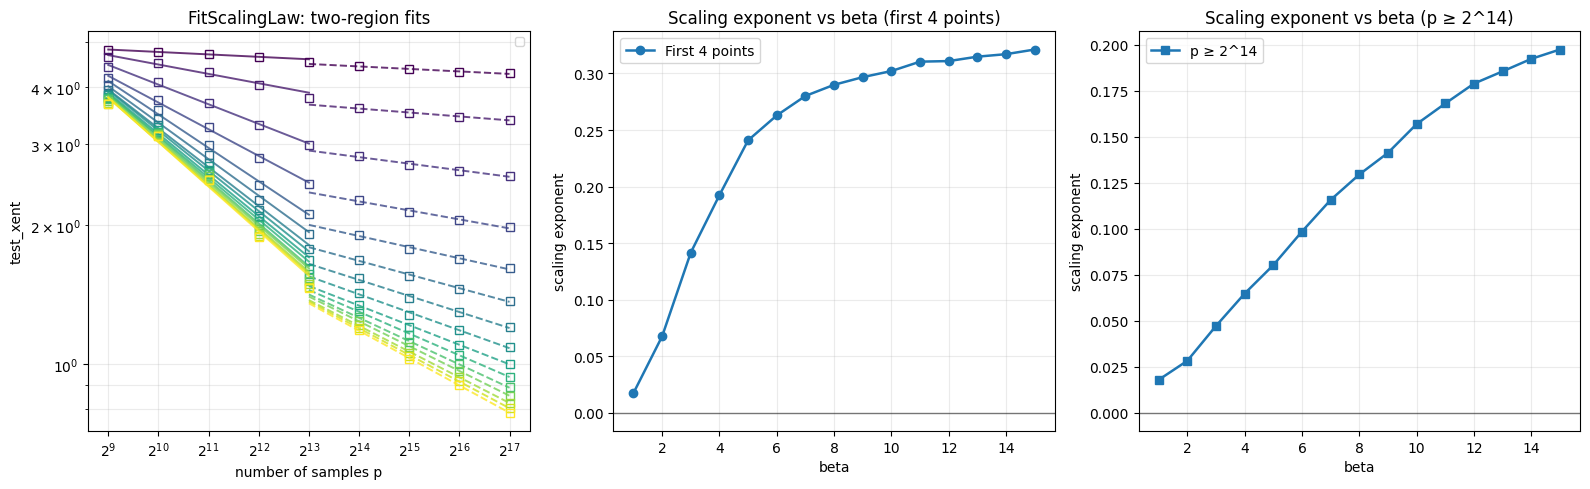

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# First subplot: scaling law with two fits
ax = axes[0]
cmap = plt.get_cmap('viridis')
for color_idx, beta in enumerate(betas):
    group = final[final['beta'] == beta].sort_values('p')
    if group.empty:
        continue
    
    color = cmap(color_idx / max(1, len(betas) - 1))
    
    # First fit (first 4 points)
    fit_first4_row = fits_first4[fits_first4['beta'] == beta].iloc[0]
    p_grid_first4 = np.geomspace(group['p'].min(), 2**13, 100)
    y_fit_first4 = np.exp(fit_first4_row['intercept']) * p_grid_first4 ** fit_first4_row['slope']
    ax.plot(p_grid_first4, y_fit_first4, linewidth=1.4, color=color, alpha=0.8)
    
    # Second fit (p >= 2^14)
    group_large_p = group[group['p'] >= 2**14]
    if len(group_large_p) >= 2:
        x_large = np.log(group_large_p['p'].values)
        y_large = np.log(group_large_p[metric].values)
        slope_large, intercept_large = np.polyfit(x_large, y_large, 1)
        
        p_grid_large = np.geomspace(2**13, group['p'].max(), 100)
        y_fit_large = np.exp(intercept_large) * p_grid_large ** slope_large
        ax.plot(p_grid_large, y_fit_large, linewidth=1.4, color=color, alpha=0.8, linestyle='--')
    
    # Plot data points
    full_batch = group[group['mode'] == 'population']
    minibatch = group[group['mode'] != 'population']
    if not full_batch.empty:
        ax.plot(full_batch['p'], full_batch[metric], marker='o', linestyle='', color=color,
                label=f"beta={beta:g}")
    if not minibatch.empty:
        ax.plot(minibatch['p'], minibatch[metric], marker='s', linestyle='', color=color, markerfacecolor='none')

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('number of samples p')
ax.set_ylabel(metric)
ax.set_title('FitScalingLaw: two-region fits')
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize='small', ncols=2)

# Second subplot: scaling exponent vs beta (first 4 points fit)
ax = axes[1]
ax.plot(fits_first4['beta'], fits_first4['scaling_exponent'], marker='o', linewidth=1.8, label='First 4 points')
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.set_xlabel('beta')
ax.set_ylabel('scaling exponent')
ax.set_title('Scaling exponent vs beta (first 4 points)')
ax.grid(True, alpha=0.25)
ax.legend()

# Third subplot: scaling exponent vs beta (large p fit)
ax = axes[2]
fits_large_p = []
for beta in betas:
    group = final[final['beta'] == beta].sort_values('p')
    group_large_p = group[group['p'] >= 2**14]
    if len(group_large_p) >= 2:
        x_large = np.log(group_large_p['p'].values)
        y_large = np.log(group_large_p[metric].values)
        slope_large, intercept_large = np.polyfit(x_large, y_large, 1)
        fits_large_p.append({'beta': beta, 'scaling_exponent': -slope_large})

fits_large_p_df = pd.DataFrame(fits_large_p)
ax.plot(fits_large_p_df['beta'], fits_large_p_df['scaling_exponent'], marker='s', linewidth=1.8, label='p ≥ 2^14')
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.set_xlabel('beta')
ax.set_ylabel('scaling exponent')
ax.set_title('Scaling exponent vs beta (p ≥ 2^14)')
ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(plot_dir / f'fit_scaling_law_{metric}_two_region_analysis.png', dpi=180)
plt.show()

## Three-Parameter Scaling Law Fit ($A + B p^{-c}$)

Here we fit the curve $f(p) = A + B p^{-c}$ in log-space (minimizing the squared error between $\log(y)$ and $\log(A + B p^{-c})$) using non-linear least squares optimization.

In [7]:
from scripts.process_scaling_law import fit_scaling_law_abc

fits_abc = fit_scaling_law_abc(final, metric)
fits_abc.to_csv(run_root / 'scaling_law_exponents_abc.csv', index=False)
fits_abc

,beta,metric,A,B,c,scaling_exponent,r2,n_points
0,1.0,test_xent,0.263776,5.340550,0.024826,0.024826,0.985596,9
1,2.0,test_xent,2.811507,8.204512,0.232408,0.232408,0.983532,9
2,3.0,test_xent,2.235741,22.885189,0.369634,0.369634,0.992795,9
3,4.0,test_xent,1.678470,33.291263,0.407789,0.407789,0.993657,9
4,5.0,test_xent,1.353089,46.366301,0.447902,0.447902,0.993953,9
5,6.0,test_xent,1.097531,48.398088,0.446067,0.446067,0.994093,9
6,7.0,test_xent,0.920769,50.273797,0.445839,0.445839,0.994621,9
7,8.0,test_xent,0.794069,52.395123,0.446059,0.446059,0.994033,9
8,9.0,test_xent,0.704418,53.097977,0.445434,0.445434,0.993893,9
9,10.0,test_xent,0.627361,50.897349,0.436495,0.436495,0.994564,9


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


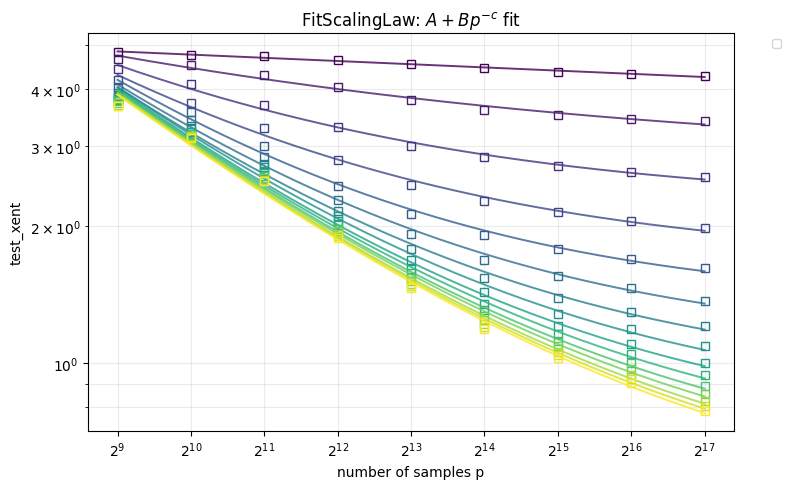

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.get_cmap('viridis')
betas = sorted(final['beta'].unique())
for color_idx, beta in enumerate(betas):
    group = final[final['beta'] == beta].sort_values('p')
    fit = fits_abc[fits_abc['beta'] == beta].iloc[0]
    
    if np.isnan(fit['A']):
        continue
        
    color = cmap(color_idx / max(1, len(betas) - 1))
    p_grid = np.geomspace(group['p'].min(), group['p'].max(), 200)
    y_fit = fit['A'] + fit['B'] * p_grid ** (-fit['c'])
    full_batch = group[group['mode'] == 'population']
    minibatch = group[group['mode'] != 'population']
    
    if not full_batch.empty:
        ax.plot(full_batch['p'], full_batch[metric], marker='o', linestyle='', color=color, label=f"beta={beta:g}, c={fit['c']:.3f}")
    if not minibatch.empty:
        ax.plot(minibatch['p'], minibatch[metric], marker='s', linestyle='', color=color, markerfacecolor='none')
    ax.plot(p_grid, y_fit, linewidth=1.4, color=color, alpha=0.8)

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('number of samples p')
ax.set_ylabel(metric)
ax.set_title(rf'FitScalingLaw: $A + B p^{{-c}}$ fit')
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize='small', ncols=2, bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout()
fig.savefig(plot_dir / f'fit_scaling_law_{metric}_abc_loglog.png', dpi=180)
plt.show()

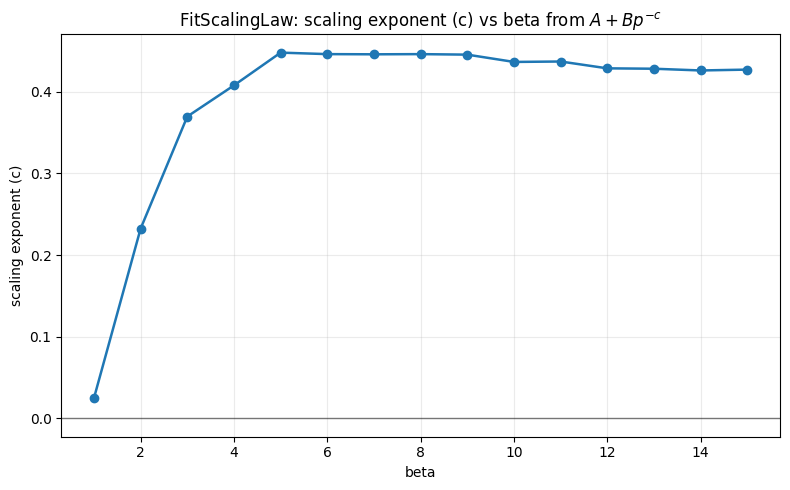

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
valid_fits = fits_abc.dropna(subset=['A'])
ax.plot(valid_fits['beta'], valid_fits['scaling_exponent'], marker='o', linewidth=1.8)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.set_xlabel('beta')
ax.set_ylabel('scaling exponent (c)')
ax.set_title(r'FitScalingLaw: scaling exponent (c) vs beta from $A + B p^{-c}$')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(plot_dir / f'fit_scaling_law_{metric}_exponent_vs_beta_abc.png', dpi=180)
plt.show()

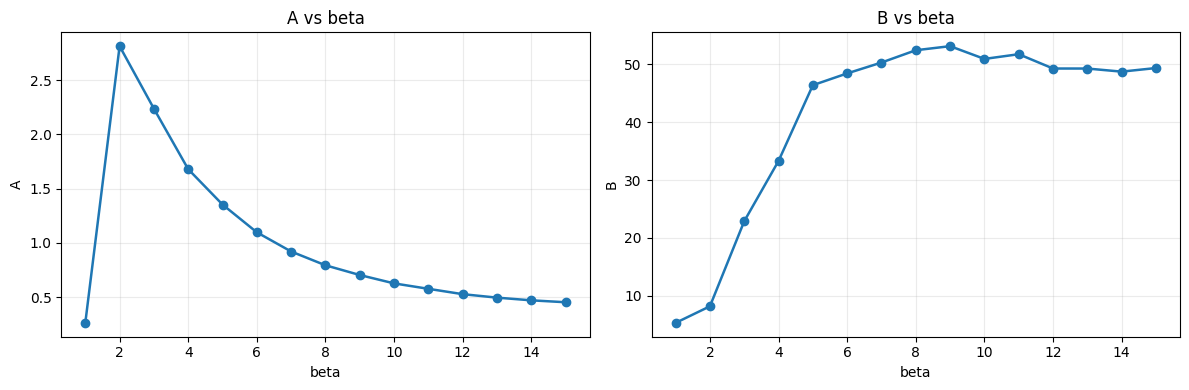

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# A vs beta
ax = axes[0]
ax.plot(fits_abc['beta'], fits_abc['A'], marker='o', linewidth=1.8)
ax.set_xlabel('beta')
ax.set_ylabel('A')
ax.set_title('A vs beta')
ax.grid(True, alpha=0.25)

# B vs beta
ax = axes[1]
ax.plot(fits_abc['beta'], fits_abc['B'], marker='o', linewidth=1.8)
ax.set_xlabel('beta')
ax.set_ylabel('B')
ax.set_title('B vs beta')
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(plot_dir / f'fit_scaling_law_{metric}_A_B_vs_beta.png', dpi=180)
plt.show()

## Alpha 0 FitScalingLaw

This section analyzes the separate teacher $\alpha=0$ sweep over $p \in \{2^9,2^{10},\ldots,2^{16}\}$ and $\beta \in \{1,\ldots,12\}$. It uses the same minibatch SGD rule with batch size $2^{11}$ and $T_{\mathrm{minibatch}}=2000p/2^{11}$ steps.

In [11]:
alpha0_run_root = repo_root / 'runs/fit_scaling_law_alpha0_20260512'
alpha0_plot_dir = alpha0_run_root
alpha0_plot_dir.mkdir(parents=True, exist_ok=True)
alpha0_paths = sorted(alpha0_run_root.glob('beta-*_p-*.csv'))
len(alpha0_paths)

96

In [12]:
if alpha0_paths:
    alpha0_df = load_scaling_results(alpha0_run_root)
    alpha0_df.to_csv(alpha0_run_root / 'scaling_law_results.csv', index=False)

    alpha0_final = final_losses(alpha0_df, metric)
    if 'mode' not in alpha0_final.columns:
        alpha0_final['mode'] = 'population'
    else:
        alpha0_final['mode'] = alpha0_final['mode'].fillna('population')
    alpha0_final.to_csv(alpha0_run_root / 'scaling_law_final_losses.csv', index=False)

    alpha0_fits = fit_scaling_exponents(alpha0_final, metric)
    alpha0_fits.to_csv(alpha0_run_root / 'scaling_law_exponents.csv', index=False)

    alpha0_fits_abc = fit_scaling_law_abc(alpha0_final, metric)
    alpha0_fits_abc.to_csv(alpha0_run_root / 'scaling_law_exponents_abc.csv', index=False)
else:
    alpha0_df = pd.DataFrame()
    alpha0_final = pd.DataFrame()
    alpha0_fits = pd.DataFrame()
    alpha0_fits_abc = pd.DataFrame()

alpha0_fits_abc

,beta,metric,A,B,c,scaling_exponent,r2,n_points
0,1.0,test_xent,9.766599e-16,29.406238,0.272386,0.272386,0.955497,8
1,2.0,test_xent,6.591596e-25,32.855347,0.301040,0.301040,0.977843,8
2,3.0,test_xent,7.881075e-02,32.034027,0.313266,0.313266,0.981920,8
3,4.0,test_xent,3.563893e-01,39.845829,0.361700,0.361700,0.981642,8
4,5.0,test_xent,4.543666e-01,43.897895,0.382330,0.382330,0.981297,8
5,6.0,test_xent,4.945042e-01,45.491624,0.390649,0.390649,0.981367,8
6,7.0,test_xent,5.151904e-01,46.520295,0.395428,0.395428,0.981507,8
7,8.0,test_xent,5.309347e-01,47.733297,0.400070,0.400070,0.981170,8
8,9.0,test_xent,5.393758e-01,48.246898,0.402231,0.402231,0.981444,8
9,10.0,test_xent,5.471866e-01,48.931233,0.404615,0.404615,0.981659,8


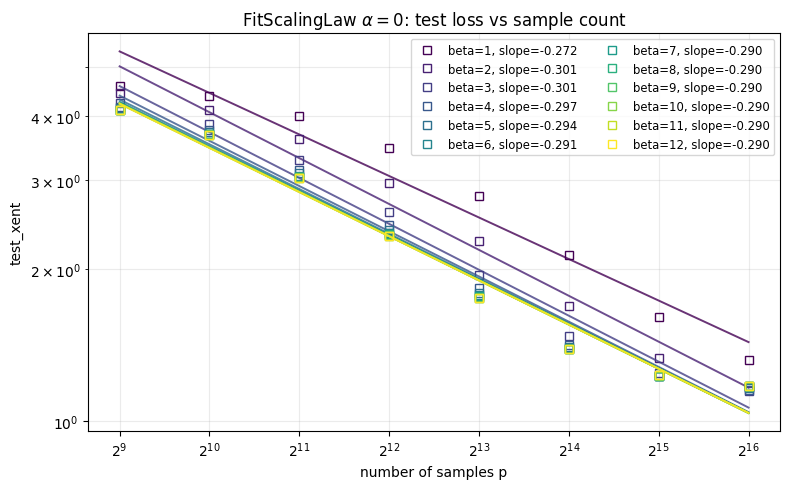

In [13]:
if not alpha0_final.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    cmap = plt.get_cmap('viridis')
    betas = sorted(alpha0_final['beta'].unique())
    for color_idx, beta in enumerate(betas):
        group = alpha0_final[alpha0_final['beta'] == beta].sort_values('p')
        fit = alpha0_fits[alpha0_fits['beta'] == beta].iloc[0]
        color = cmap(color_idx / max(1, len(betas) - 1))
        p_grid = np.geomspace(group['p'].min(), group['p'].max(), 200)
        y_fit = np.exp(fit['intercept']) * p_grid ** fit['slope']
        ax.plot(group['p'], group[metric], marker='s', linestyle='', color=color, markerfacecolor='none', label=f"beta={beta:g}, slope={fit['slope']:.3f}")
        ax.plot(p_grid, y_fit, linewidth=1.4, color=color, alpha=0.8)

    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('number of samples p')
    ax.set_ylabel(metric)
    ax.set_title(r'FitScalingLaw $\alpha=0$: test loss vs sample count')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize='small', ncols=2)
    fig.tight_layout()
    fig.savefig(alpha0_plot_dir / f'fit_scaling_law_alpha0_{metric}_loglog.png', dpi=180)
    plt.show()

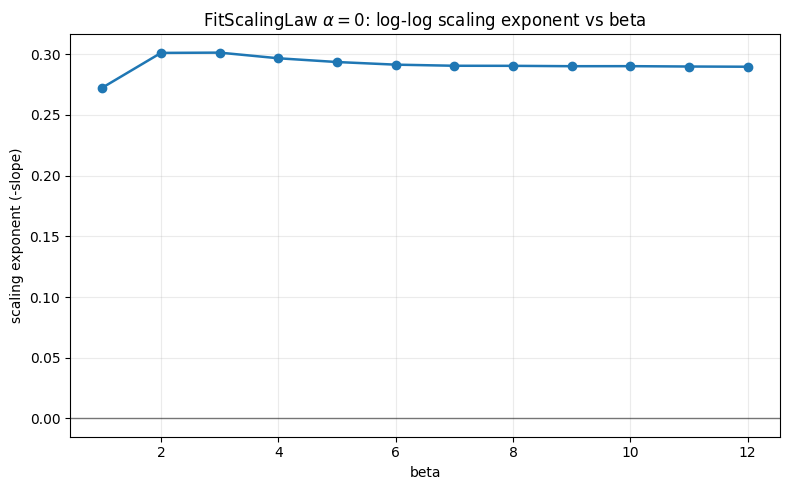

In [14]:
if not alpha0_fits.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(alpha0_fits['beta'], alpha0_fits['scaling_exponent'], marker='o', linewidth=1.8)
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xlabel('beta')
    ax.set_ylabel('scaling exponent (-slope)')
    ax.set_title(r'FitScalingLaw $\alpha=0$: log-log scaling exponent vs beta')
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(alpha0_plot_dir / f'fit_scaling_law_alpha0_{metric}_exponent_vs_beta.png', dpi=180)
    plt.show()

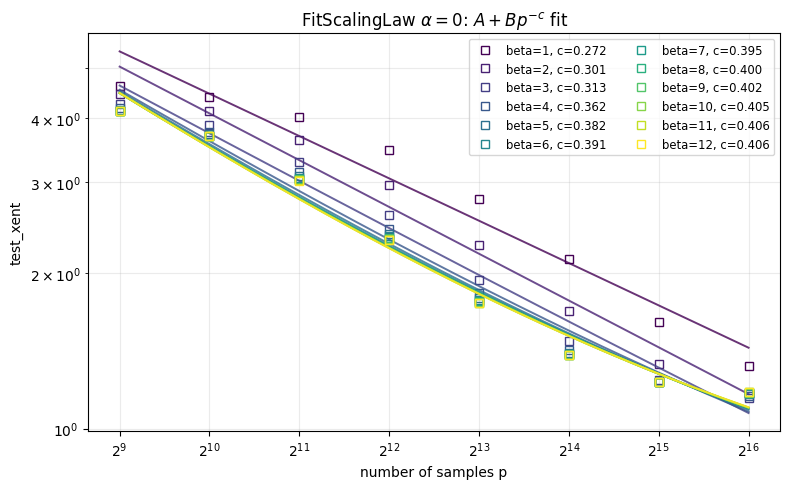

In [15]:
if not alpha0_final.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    cmap = plt.get_cmap('viridis')
    betas = sorted(alpha0_final['beta'].unique())
    for color_idx, beta in enumerate(betas):
        group = alpha0_final[alpha0_final['beta'] == beta].sort_values('p')
        fit = alpha0_fits_abc[alpha0_fits_abc['beta'] == beta].iloc[0]
        if np.isnan(fit['A']):
            continue
        color = cmap(color_idx / max(1, len(betas) - 1))
        p_grid = np.geomspace(group['p'].min(), group['p'].max(), 200)
        y_fit = fit['A'] + fit['B'] * p_grid ** (-fit['c'])
        ax.plot(group['p'], group[metric], marker='s', linestyle='', color=color, markerfacecolor='none', label=f"beta={beta:g}, c={fit['c']:.3f}")
        ax.plot(p_grid, y_fit, linewidth=1.4, color=color, alpha=0.8)

    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('number of samples p')
    ax.set_ylabel(metric)
    ax.set_title(r'FitScalingLaw $\alpha=0$: $A + B p^{-c}$ fit')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize='small', ncols=2)
    fig.tight_layout()
    fig.savefig(alpha0_plot_dir / f'fit_scaling_law_alpha0_{metric}_loglog_abc.png', dpi=180)
    plt.show()

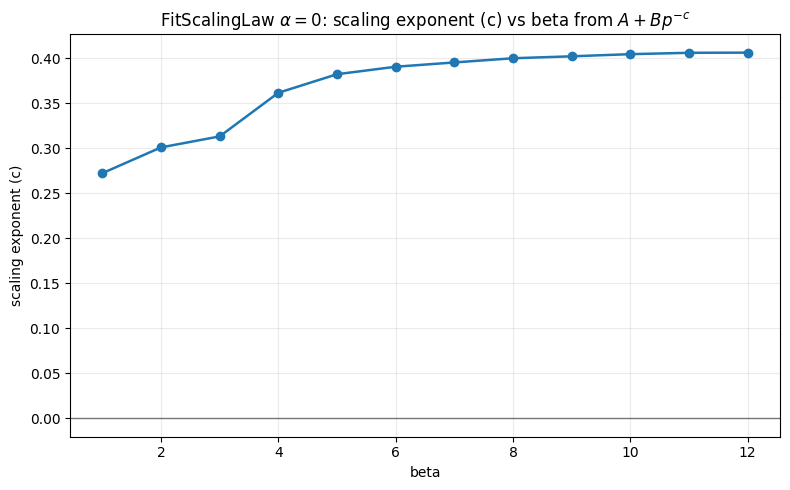

In [16]:
if not alpha0_fits_abc.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    valid_alpha0_fits = alpha0_fits_abc.dropna(subset=['A'])
    ax.plot(valid_alpha0_fits['beta'], valid_alpha0_fits['scaling_exponent'], marker='o', linewidth=1.8)
    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xlabel('beta')
    ax.set_ylabel('scaling exponent (c)')
    ax.set_title(r'FitScalingLaw $\alpha=0$: scaling exponent (c) vs beta from $A + B p^{-c}$')
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(alpha0_plot_dir / f'fit_scaling_law_alpha0_{metric}_exponent_vs_beta_abc.png', dpi=180)
    plt.show()